In [1]:
import numpy as np
import matplotlib.pyplot as plt

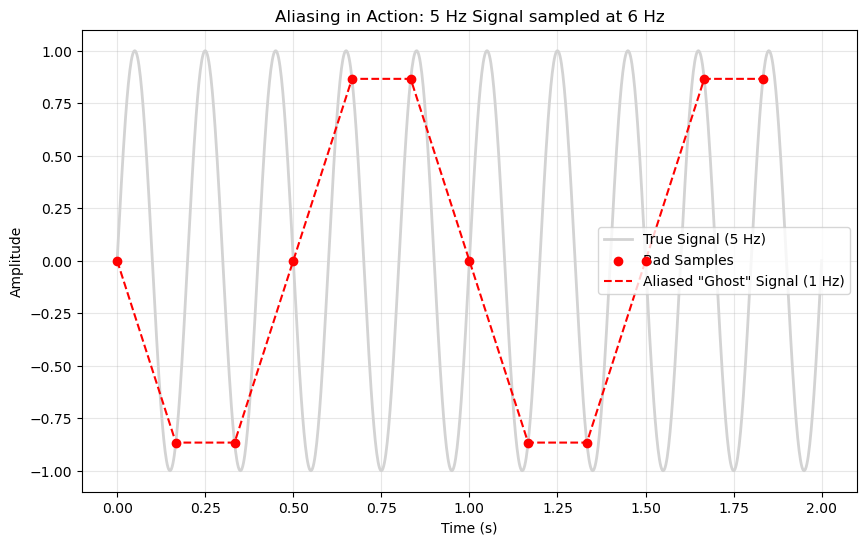

In [2]:

# 1. Setup the "Continuous" Reality (High resolution)
t_continuous = np.linspace(0, 2, 1000) # 2 seconds
f_signal = 5  # 5 Hz signal
signal_continuous = np.sin(2 * np.pi * f_signal * t_continuous)

# 2. Setup the "Bad" Sampler
fs_bad = 6    # Sampling at 6 Hz (Violates Nyquist: 6 < 2*5)
t_bad = np.arange(0, 2, 1/fs_bad)
signal_bad = np.sin(2 * np.pi * f_signal * t_bad)

# 3. Visualization
plt.figure(figsize=(10, 6))

# Plot the true reality
plt.plot(t_continuous, signal_continuous, label='True Signal (5 Hz)', color='lightgray', linewidth=2)

# Plot the samples we actually recorded
plt.scatter(t_bad, signal_bad, color='red', zorder=10, label='Bad Samples')

# Connect the dots (Interpolation) to show what the computer "thinks" it sees
plt.plot(t_bad, signal_bad, 'r--', label='Aliased "Ghost" Signal (1 Hz)')

plt.title(f'Aliasing in Action: 5 Hz Signal sampled at {fs_bad} Hz')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

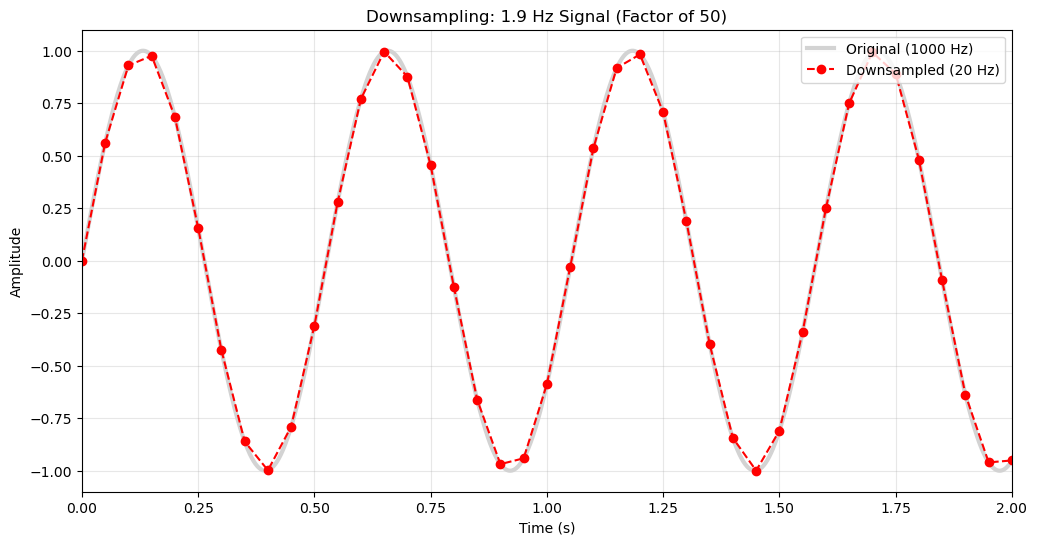

In [3]:
# 1. Parameters
duration = 10         # Seconds
freq_signal = 1.9     # Hz (19 full cycles in 10s)
fs_original = 1000    # Hz (Original Sampling Rate)
downsample_factor = 50

# 2. Create the Original Signal
# N = 10,000 samples (10s * 1000 Hz)
t_original = np.linspace(0, duration, int(duration * fs_original), endpoint=False)
x_original = np.sin(2 * np.pi * freq_signal * t_original)

# 3. Downsample (Decimate)
# We take every 50th sample using array slicing [::50]
# New fs = 1000 / 50 = 20 Hz
x_down = x_original[::downsample_factor]
t_down = t_original[::downsample_factor]

# 4. Plotting
plt.figure(figsize=(12, 6))

# Plot Original (High Res)
plt.plot(t_original, x_original, label='Original (1000 Hz)', color='lightgray', linewidth=3)

# Plot Downsampled (Low Res)
# Note: marker='o' shows the actual sample points
plt.plot(t_down, x_down, label='Downsampled (20 Hz)', color='red', marker='o', linestyle='--')

plt.title(f'Downsampling: 1.9 Hz Signal (Factor of {downsample_factor})')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Zoom in on the first 2 seconds so we can actually see the dots clearly
plt.xlim(0, 2) 
plt.show()

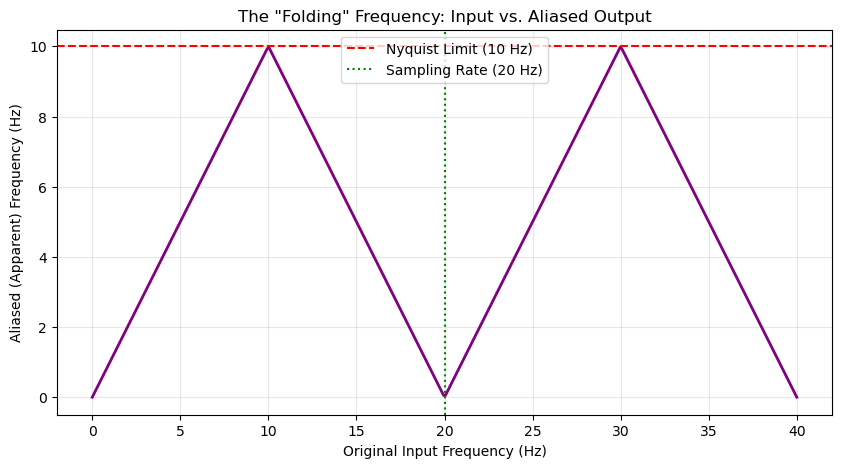

In [4]:
def calculate_alias(f_input, f_nyquist):
    fs = 2 * f_nyquist
    # The General Formula: Distance to nearest multiple of fs
    # np.round finds the nearest integer k
    k = np.round(f_input / fs)
    return np.abs(f_input - k * fs)

# 1. Setup
f_nyquist = 10  # Nyquist limit is 10 Hz (Sampling at 20 Hz)
f_inputs = np.linspace(0, 40, 400) # Test frequencies from 0 to 40 Hz

# 2. Calculate Aliases
f_outputs = calculate_alias(f_inputs, f_nyquist)

# 3. Plot
plt.figure(figsize=(10, 5))
plt.plot(f_inputs, f_outputs, linewidth=2, color='purple')

# Add visual guides
plt.axhline(f_nyquist, color='red', linestyle='--', label='Nyquist Limit (10 Hz)')
plt.axvline(2*f_nyquist, color='green', linestyle=':', label='Sampling Rate (20 Hz)')

plt.title('The "Folding" Frequency: Input vs. Aliased Output')
plt.xlabel('Original Input Frequency (Hz)')
plt.ylabel('Aliased (Apparent) Frequency (Hz)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

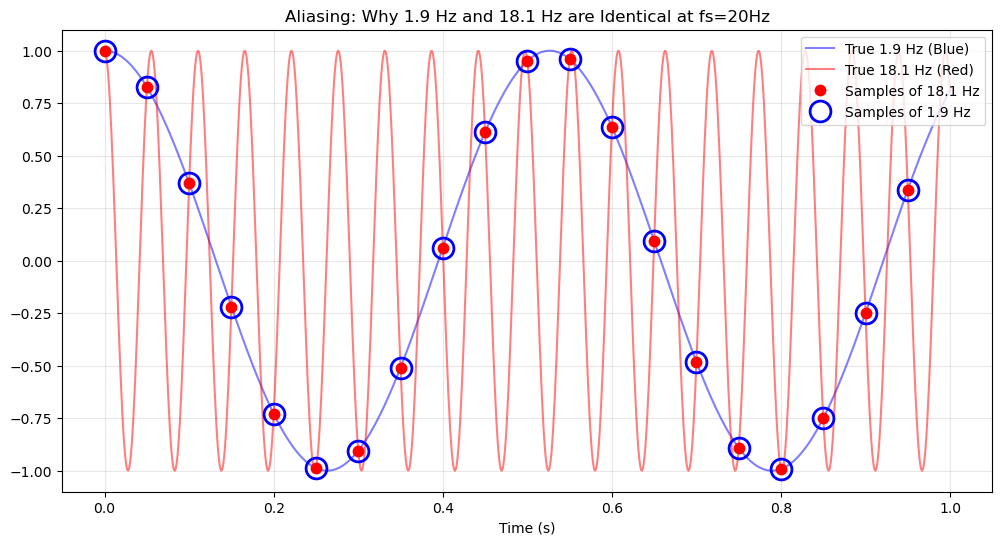

Maximum difference between the two sampled signals: 0.0000000000


In [5]:
# 1. Setup
fs_sample = 20       # Your downsampled rate
duration = 1.0       # Look at just 1 second
t_continuous = np.linspace(0, duration, 1000) # High res time for "Truth"
t_sample = np.arange(0, duration, 1/fs_sample) # The sample moments

# 2. Define the two different "Realities"
# Signal A: Your original signal
freq_A = 1.9 
sig_A_true = np.cos(2 * np.pi * freq_A * t_continuous)
sig_A_samples = np.cos(2 * np.pi * freq_A * t_sample)

# Signal B: The "Imposter" (18.1 Hz)
# 18.1 Hz is exactly 1.9 Hz away from 20 Hz
freq_B = 18.1 
sig_B_true = np.cos(2 * np.pi * freq_B * t_continuous)
sig_B_samples = np.cos(2 * np.pi * freq_B * t_sample)

# 3. Plotting
plt.figure(figsize=(12, 6))

# Plot the "Truth" (The continuous reality)
plt.plot(t_continuous, sig_A_true, 'b-', alpha=0.5, label='True 1.9 Hz (Blue)')
plt.plot(t_continuous, sig_B_true, 'r-', alpha=0.5, label='True 18.1 Hz (Red)')

# Plot the Samples (What the computer sees)
# We plot the 18.1 Hz samples as red dots, and 1.9 Hz as blue circles
plt.plot(t_sample, sig_B_samples, 'r.', markersize=15, label='Samples of 18.1 Hz')
plt.plot(t_sample, sig_A_samples, 'bo', fillstyle='none', markersize=15, markeredgewidth=2, label='Samples of 1.9 Hz')

plt.title(f'Aliasing: Why 1.9 Hz and 18.1 Hz are Identical at fs={fs_sample}Hz')
plt.xlabel('Time (s)')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.show()

# 4. The "Proof"
# Let's check the error between the two lists of numbers
difference = np.max(np.abs(sig_A_samples - sig_B_samples))
print(f"Maximum difference between the two sampled signals: {difference:.10f}")